## **MDQ Project**
  - An end-to-end AI solution for discovering hidden commercial activity among physical persons using transaction analytics, clustering, and predictive modeling.

  Team name: The Ace of tech

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [2]:
business = pd.read_parquet("business_cards_MDQ.parquet")
consumer = pd.read_parquet("consumer_cards_MDQ.parquet")
merchants = pd.read_parquet("merchants_reference.parquet")

In [3]:
# размеры датасетов
print("Business shape:", business.shape)
print("Consumer shape:", consumer.shape)
print("Merchants shape:", merchants.shape)

Business shape: (2997593, 12)
Consumer shape: (9832487, 12)
Merchants shape: (2165, 5)


In [13]:
# просматриваем колонки и типы данных
print("Business columns:")
print(business.columns.tolist())
print(business.dtypes)
print(business.info())
print("\n")  # добавляем пустую строку для разделения вывода

print("\nConsumer columns:")
print(consumer.columns.tolist())
print(consumer.dtypes)
print(consumer.info())


print("\nMerchants columns:")
print(merchants.columns.tolist())
print(merchants.dtypes)
print(merchants.info())

Business columns:
['transaction_date', 'transaction_timestamp', 'transaction_amount_kzt', 'mcc', 'merchant_id', 'channel', 'bank_name', 'country', 'card_number', 'card_tier', 'tokenized', 'is_recurring']
transaction_date                  object
transaction_timestamp     datetime64[ms]
transaction_amount_kzt             int64
mcc                               object
merchant_id                       object
channel                           object
bank_name                         object
country                           object
card_number                       object
card_tier                         object
tokenized                           bool
is_recurring                        bool
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997593 entries, 0 to 2997592
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_date        object        
 1   transaction_timestamp   datetime64[ms]
 

#### Смотрим первые колонки\данные

In [6]:
business.head()


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True


In [7]:
consumer.head()

,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,2025-10-01,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,2025-10-01,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True
3,2025-10-01,2025-10-01 00:37:00,6078,4814,MER_000063,online,Home Credit Bank,Kazakhstan,5338472125333693,Standard,False,True
4,2025-10-01,2025-10-01 00:37:00,6042,4814,MER_000065,online,Kaspi,Kazakhstan,5531514712394557,Affluent,False,True


In [8]:
merchants.head()

,merchant_id,merchant_name,mcc,merchant_country,recurring_capable
0,MER_000000,Google Ads,7311,Ireland,True
1,MER_000001,Meta Ads,7311,Ireland,True
2,MER_000002,TikTok Ads,7311,Singapore,True
3,MER_000003,Yandex Direct,7311,Russia,True
4,MER_000004,LinkedIn Ads,7311,Ireland,True


In [14]:
business.isna().sum().sort_values(ascending=False) # проверяем пропуски в бизнес датасете

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64

In [15]:
consumer.isna().sum().sort_values(ascending=False) # проверяем пропуски в потребительском датасете

transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64

In [16]:
merchants.isna().sum().sort_values(ascending=False) # проверяем пропуски в датасете с информацией о торговых точках

merchant_id          0
merchant_name        0
mcc                  0
merchant_country     0
recurring_capable    0
dtype: int64

In [18]:
# проверяем дупликаты в бизнес датасете
print("Business duplicates:", business.duplicated().sum())

Business duplicates: 0


In [19]:
# дупликаты в потребительском датасете
print("Consumer duplicates:", consumer.duplicated().sum())

Consumer duplicates: 0


In [20]:
# дупликаты в потребительском датасете
print("Consumer duplicates:", consumer.duplicated().sum())

Consumer duplicates: 0


In [21]:
# добавляем таргет
business["target"] = 1 # business behavior
consumer["target"] = 0 # consumer behavior

In [22]:
# Объединяем датасеты (business и consumer) для дальнейшего анализа
data = pd.concat([business, consumer], ignore_index=True)

print(data.shape)
data.head()

(12830080, 13)


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring,target
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True,1
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True,1
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True,1
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True,1
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True,1


In [23]:
# проверяем баланс классов
print("Class distribution:")
print(data["target"].value_counts())
data["target"].value_counts(normalize=True) * 100

Class distribution:
target
0    9832487
1    2997593
Name: count, dtype: int64


target
0    76.63621
1    23.36379
Name: proportion, dtype: float64

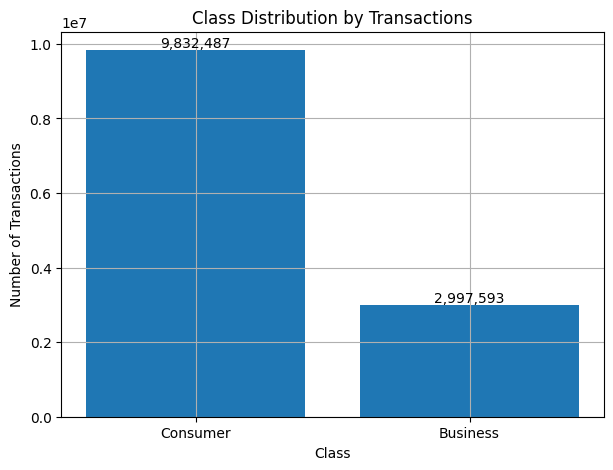

In [48]:
class_counts = data["target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], class_counts.values)

plt.title("Class Distribution by Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

for i, value in enumerate(class_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

#### **Class Distribution**

At the current stage, class distribution is calculated on the transaction level rather than the card level.

Current dataset balance:
- Consumer transactions: 76.6%
- Business transactions: 23.4%

Further during data preprocessing, aggregation by `card_number` will be performed, transforming the dataset into:
    
1 row = 1 card

This approach is more appropriate for behavioral modeling and helps reduce data leakage and overfitting.


This chart shows the class distribution at the transaction level. Consumer transactions dominate the dataset, while business transactions represent a smaller but still significant part of the data. Later, after aggregation, the balance will be recalculated at the card level.

In [24]:
# проверяем есть ли merchant_id
print("Merchant ID in business dataset:", "merchant_id" in business.columns)
print("Merchant ID in consumer dataset:", "merchant_id" in consumer.columns)

Merchant ID in business dataset: True
Merchant ID in consumer dataset: True


In [25]:
data = data.merge(
    merchants,
    on="merchant_id",
    how="left",
    suffixes=("", "_merchant")
)

print(data.shape)
data.head()

(12830080, 17)


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring,target,merchant_name,mcc_merchant,merchant_country,recurring_capable
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True,1,Microsoft Azure,7372,US,True
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True,1,Amazon Web Services,7372,US,True
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True,1,Microsoft Azure,7372,US,True
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True,1,Google Cloud,7372,US,True
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True,1,Yandex Direct,7311,Russia,True


#### **Merchant Reference Merge**

At this stage, an additional merge operation is performed between the transaction datasets and the `merchants_reference` table using the `merchant_id` column.

The purpose of this merge is to enrich raw transaction data with additional merchant-related business information that is not directly available in the original transaction datasets.

The `merchant_id` field serves as a unique identifier for merchants and allows linking each transaction with its corresponding merchant attributes.

After the merge, the dataset contains additional information such as:
- Merchant Category Code (MCC)
- Merchant country
- Merchant category
- Recurring payment capability
- Additional merchant behavioral attributes

This step is critically important for further feature engineering and behavioral analysis because raw transaction data alone does not provide sufficient contextual information about merchant behavior.

By enriching the dataset with merchant metadata, it becomes possible to construct advanced behavioral features such as:
- merchant concentration
- MCC diversity
- foreign merchant activity
- recurring transaction share
- merchant category patterns
- online/offline behavioral indicators

These features are highly valuable for detecting hidden SME-like behavior among consumer cardholders, since commercial activity often demonstrates distinguishable transaction patterns compared to regular consumer behavior.

The merge operation is performed using a left join to preserve all original transaction records while appending available merchant information from the reference table.


In [27]:
# базовое описание amount
data["transaction_amount_kzt"].describe()

count    1.283008e+07
mean     7.799094e+04
std      1.971753e+05
min      1.500000e+01
25%      5.028000e+03
50%      1.743100e+04
75%      6.875400e+04
max      4.079930e+07
Name: transaction_amount_kzt, dtype: float64

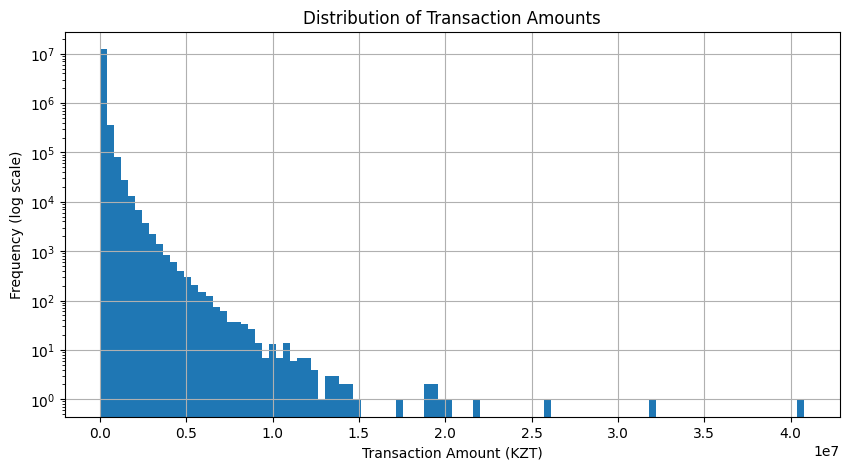

In [49]:
plt.figure(figsize=(10, 5))

plt.hist(data["transaction_amount_kzt"], bins=100, log=True)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (KZT)")
plt.ylabel("Frequency (log scale)")

plt.show()

The distribution of transaction amounts is highly skewed. Most transactions are relatively small, while a small number of transactions have very large values. This is typical for financial data and indicates the presence of high-value operations or outliers.

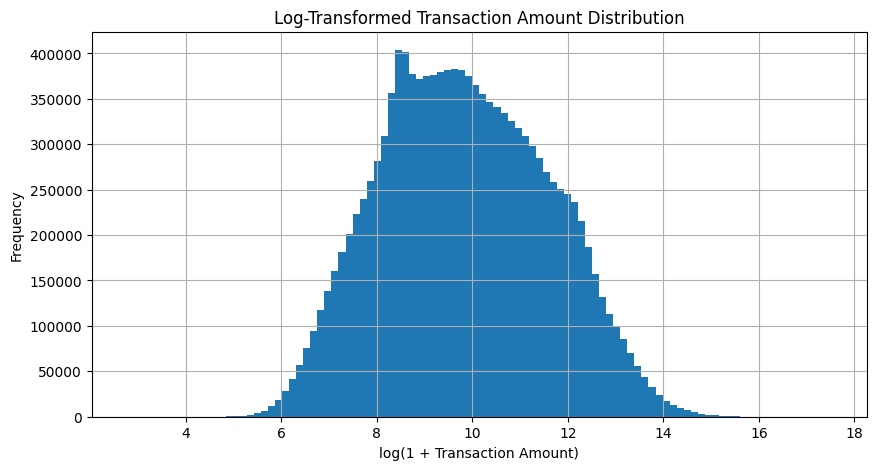

In [50]:
data["log_amount"] = np.log1p(data["transaction_amount_kzt"])

plt.figure(figsize=(10, 5))

plt.hist(data["log_amount"], bins=100)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Frequency")

plt.show()

A log transformation makes the distribution easier to interpret by reducing the impact of extreme transaction values. This helps us better see the overall transaction behavior.

#### **Transaction Amount Analysis**

At this stage, a basic analysis of transaction amounts was performed to better understand transaction behavior before feature engineering and model training.

The dataset contains approximately 12.8 million transactions. Transaction amounts are highly skewed:
- Mean transaction amount: ~77.9K KZT
- Median transaction amount: ~17.4K KZT

The significant difference between mean and median indicates the presence of large transactions and outliers, which is typical for financial datasets and may reflect business-like behavior.

Additionally, the maximum transaction amount exceeds 40 million KZT, suggesting the presence of high-turnover or potentially hidden SME activity.

This analysis helps identify transaction behavior patterns, outliers, and important signals that will later be used for behavioral feature engineering and hidden SME detection.

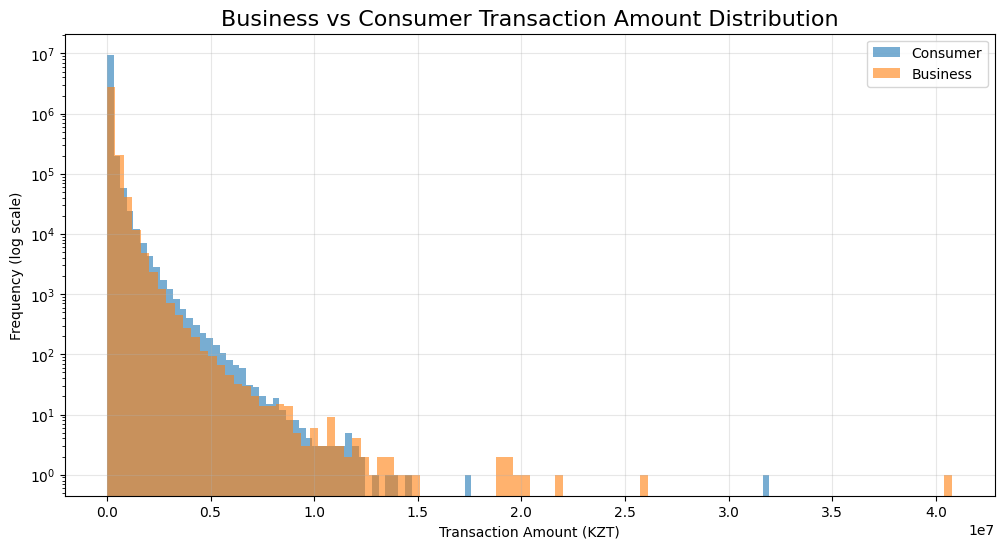

In [31]:
plt.figure(figsize=(12,6))

plt.hist(
    data[data["target"] == 0]["transaction_amount_kzt"],
    bins=100,
    alpha=0.6,
    label="Consumer",
    log=True
)

plt.hist(
    data[data["target"] == 1]["transaction_amount_kzt"],
    bins=100,
    alpha=0.6,
    label="Business",
    log=True
)

plt.title("Business vs Consumer Transaction Amount Distribution", fontsize=16)

plt.xlabel("Transaction Amount (KZT)")
plt.ylabel("Frequency (log scale)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x600 with 0 Axes>

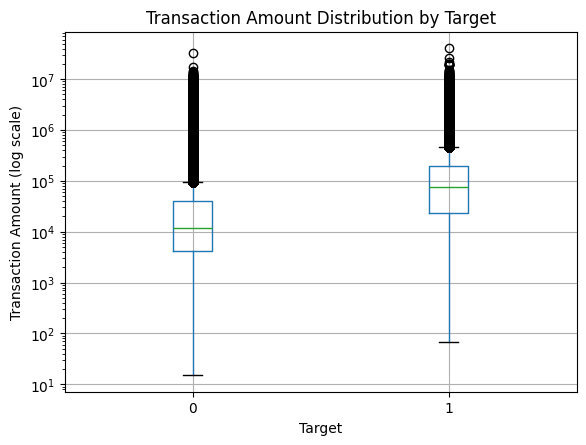

In [32]:
plt.figure(figsize=(10,6))

data.boxplot(
    column="transaction_amount_kzt",
    by="target"
)

plt.yscale("log")

plt.title("Transaction Amount Distribution by Target")
plt.suptitle("")

plt.xlabel("Target")
plt.ylabel("Transaction Amount (log scale)")

plt.show()

The visualization confirms that business cardholders generally demonstrate higher transaction volumes and more extreme transaction values compared to regular consumer cardholders.

The heavy-tailed distribution further supports the assumption that transaction amount behavior may contain strong predictive signals for hidden SME detection.

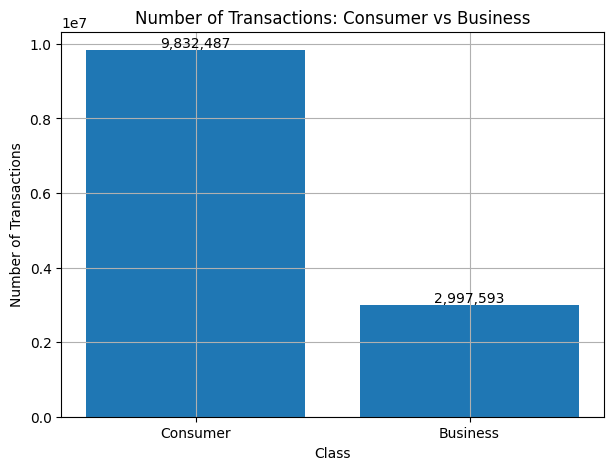

In [54]:
tx_counts = data["target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], tx_counts.values)

plt.title("Number of Transactions: Consumer vs Business")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

for i, value in enumerate(tx_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

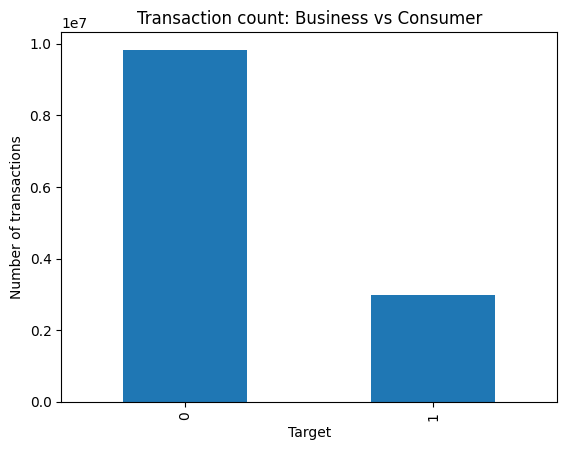

In [33]:
# Сравнить количество транзакций
data["target"].value_counts().plot(kind="bar")
plt.title("Transaction count: Business vs Consumer")
plt.xlabel("Target")
plt.ylabel("Number of transactions")
plt.show()

In [ ]:
# Сравниваем суммы транзакций
data.groupby("target")["transaction_amount_kzt"].sum()
data.groupby("target")["transaction_amount_kzt"].mean()


target
0     54045.424791
1    156535.274681
Name: transaction_amount_kzt, dtype: float64

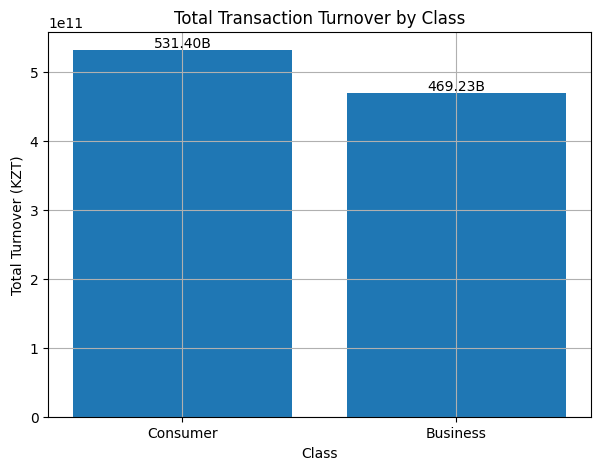

In [52]:
turnover_by_class = data.groupby("target")["transaction_amount_kzt"].sum()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], turnover_by_class.values)

plt.title("Total Transaction Turnover by Class")
plt.xlabel("Class")
plt.ylabel("Total Turnover (KZT)")

for i, value in enumerate(turnover_by_class.values):
    plt.text(i, value, f"{value/1e9:.2f}B", ha="center", va="bottom")

plt.show()

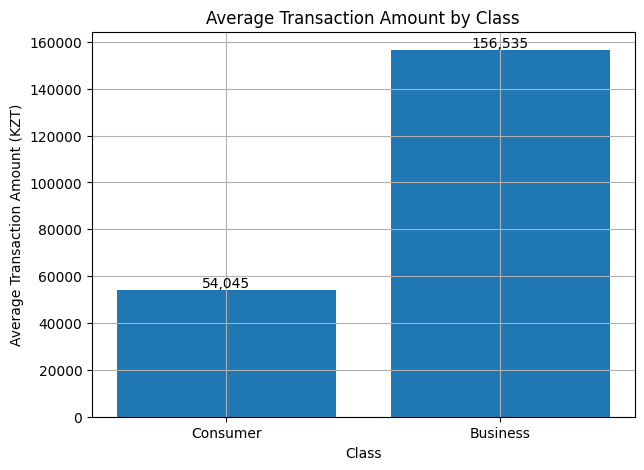

In [51]:
mean_amount = data.groupby("target")["transaction_amount_kzt"].mean()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], mean_amount.values)

plt.title("Average Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Average Transaction Amount (KZT)")

for i, value in enumerate(mean_amount.values):
    plt.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.show()

This chart shows total transaction turnover by class. Even if one class has fewer transactions, it may still represent a significant share of total transaction value, which is important for business impact analysis.

In [36]:
# Проверяем card_number
data["card_number"].nunique()

105000

In [56]:
data.groupby("target")["card_number"].nunique()

target
0    80000
1    25000
Name: card_number, dtype: int64

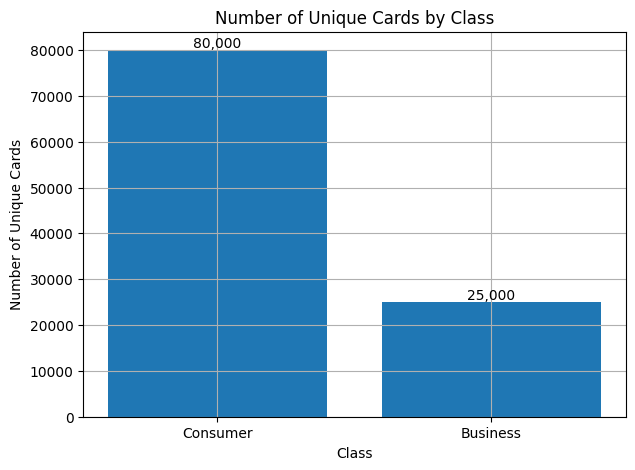

In [63]:
cards_by_class = data.groupby("target")["card_number"].nunique()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], cards_by_class.values)

plt.title("Number of Unique Cards by Class")
plt.xlabel("Class")
plt.ylabel("Number of Unique Cards")

for i, value in enumerate(cards_by_class.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

This chart shows the number of unique cards in each class. This is important because the final model will be trained at the card level, not at the transaction level.

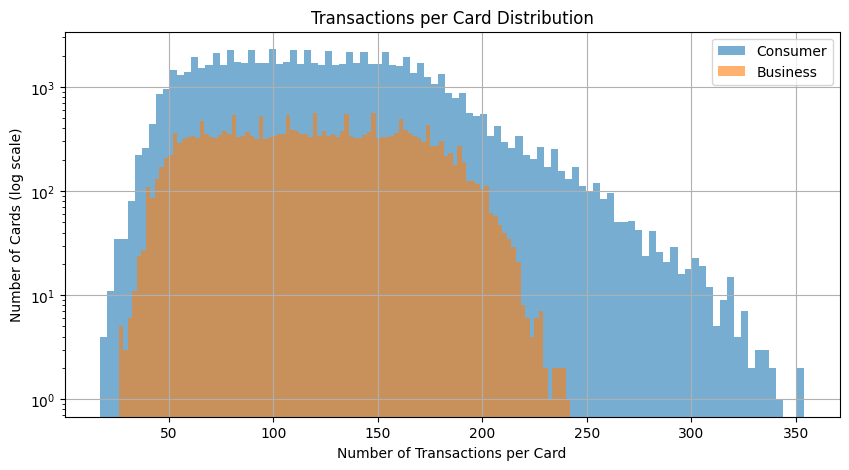

In [64]:
tx_per_card = data.groupby(["target", "card_number"]).size().reset_index(name="tx_count")

plt.figure(figsize=(10, 5))

plt.hist(
    tx_per_card[tx_per_card["target"] == 0]["tx_count"],
    bins=100,
    alpha=0.6,
    label="Consumer",
    log=True
)

plt.hist(
    tx_per_card[tx_per_card["target"] == 1]["tx_count"],
    bins=100,
    alpha=0.6,
    label="Business",
    log=True
)

plt.title("Transactions per Card Distribution")
plt.xlabel("Number of Transactions per Card")
plt.ylabel("Number of Cards (log scale)")
plt.legend()

plt.show()

This chart shows how active cards are in terms of transaction frequency. Higher transaction frequency may indicate business-like behavior, especially when combined with turnover, recurring activity, and merchant concentration.

In [57]:
# Посмотриваем merchant behavior
data.groupby("target")["merchant_id"].nunique()
data.groupby("target")["mcc"].nunique()

target
0    500
1    104
Name: mcc, dtype: int64

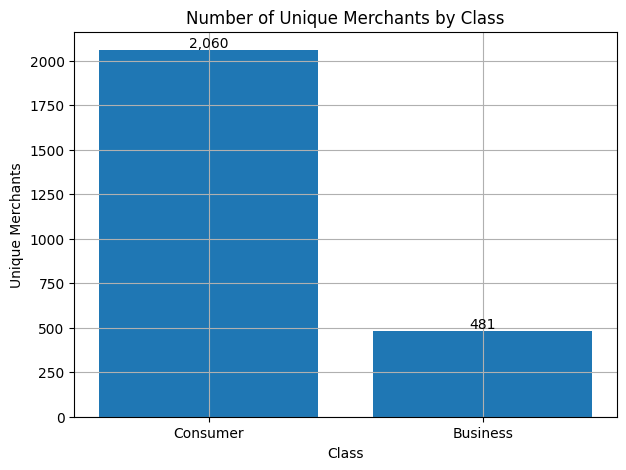

In [65]:
unique_merchants = data.groupby("target")["merchant_id"].nunique()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], unique_merchants.values)

plt.title("Number of Unique Merchants by Class")
plt.xlabel("Class")
plt.ylabel("Unique Merchants")

for i, value in enumerate(unique_merchants.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

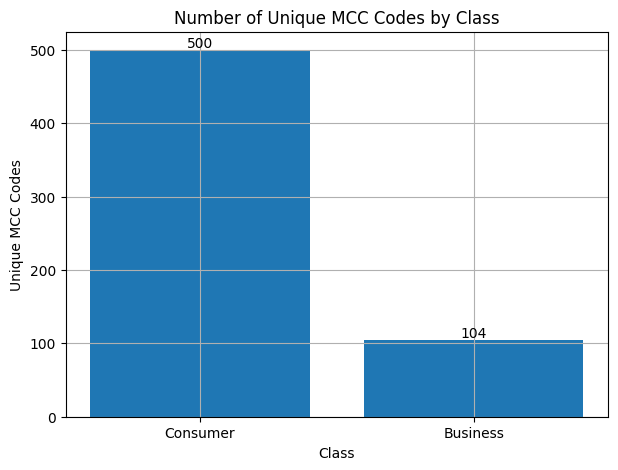

In [66]:
unique_mcc = data.groupby("target")["mcc"].nunique()

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], unique_mcc.values)

plt.title("Number of Unique MCC Codes by Class")
plt.xlabel("Class")
plt.ylabel("Unique MCC Codes")

for i, value in enumerate(unique_mcc.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

Merchant and MCC diversity help describe how broad or concentrated client activity is. Business-like clients may demonstrate specific merchant patterns or operate within business-related MCC categories.

In [58]:
# top mcc
data["mcc"].value_counts().head(20)

mcc
4814    543149
7311    527642
5812    523170
4121    432892
5541    405949
4111    296963
7372    285946
5814    271376
7011    265768
4511    264033
4899    260750
5968    252624
5311    239311
5411    224191
5999    219868
4816    217785
5912    194054
5499    172674
5542    170271
5099    169824
Name: count, dtype: int64

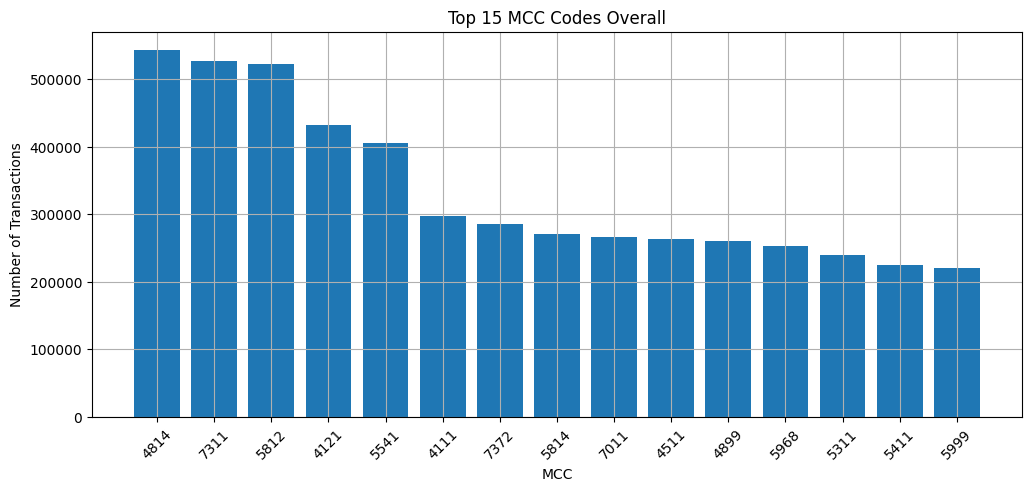

In [67]:
top_mcc = data["mcc"].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_mcc.index.astype(str), top_mcc.values)

plt.title("Top 15 MCC Codes Overall")
plt.xlabel("MCC")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [59]:
# business mcc
data[data["target"] == 1]["mcc"].value_counts().head(20)

mcc
7311    271527
7372    239687
5968    205593
4816    189791
7399    108963
7011     95045
4511     94627
5045     94044
7392     93823
4814     91669
4214     83350
4215     78547
5046     76329
5812     73732
5943     70683
5111     68603
5199     57451
5099     54924
8931     54000
7379     53646
Name: count, dtype: int64

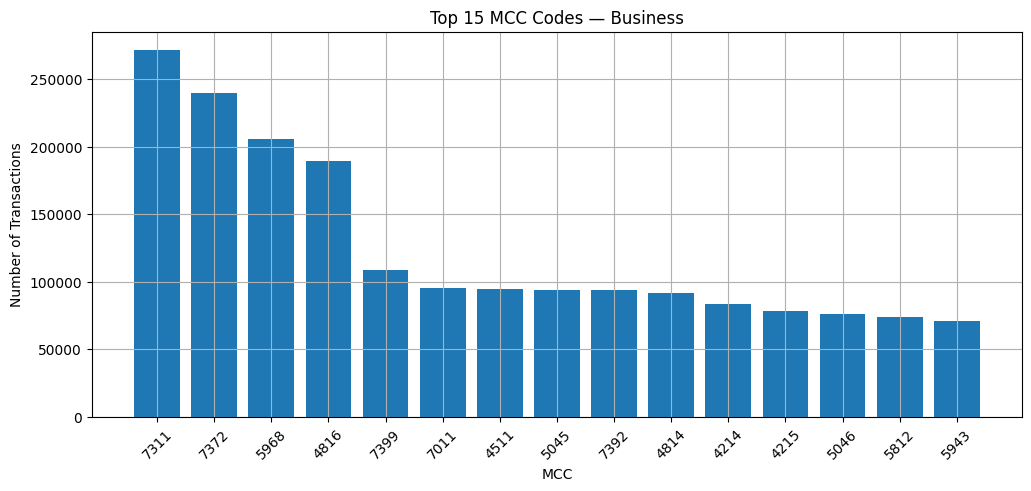

In [68]:
top_mcc_business = data[data["target"] == 1]["mcc"].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_mcc_business.index.astype(str), top_mcc_business.values)

plt.title("Top 15 MCC Codes — Business")
plt.xlabel("MCC")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [60]:
# consumer mcc
data[data["target"] == 0]["mcc"].value_counts().head(20)

mcc
4814    451480
5812    449438
4121    404310
5541    395086
4111    287214
7311    256115
5814    253705
4899    249966
5411    224191
5311    221550
5999    202094
5912    194054
7011    170723
5542    170271
5651    169442
4511    169406
5499    162351
5691    161097
5211    160430
5921    138080
Name: count, dtype: int64

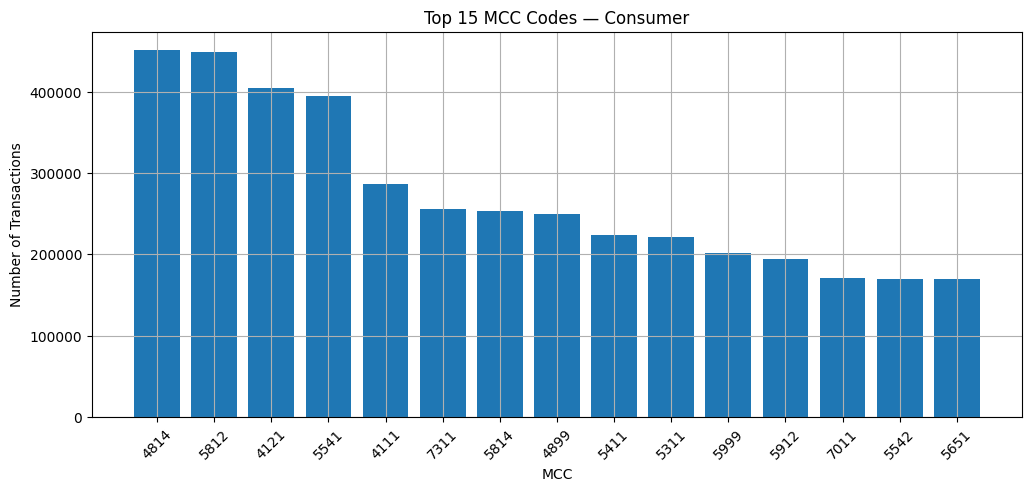

In [69]:
top_mcc_consumer = data[data["target"] == 0]["mcc"].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_mcc_consumer.index.astype(str), top_mcc_consumer.values)

plt.title("Top 15 MCC Codes — Consumer")
plt.xlabel("MCC")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

MCC analysis helps identify which merchant categories dominate business and consumer behavior. Differences in MCC structure can later be used as important features for hidden SME detection.

In [61]:
# checking recurring transactions
data.groupby("target")["is_recurring"].mean()

target
0    0.027180
1    0.133447
Name: is_recurring, dtype: float64

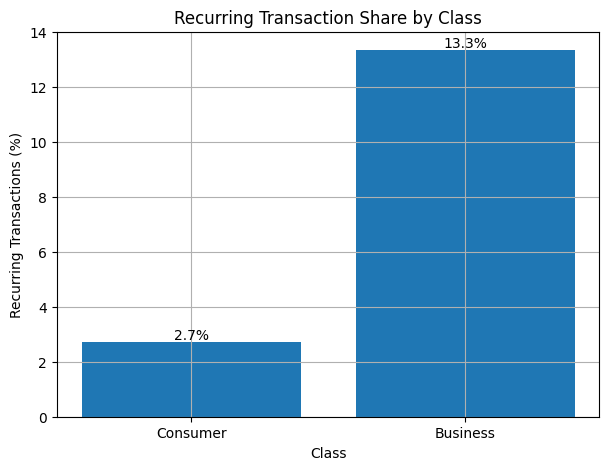

In [71]:
recurring_share = data.groupby("target")["is_recurring"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], recurring_share.values)

plt.title("Recurring Transaction Share by Class")
plt.xlabel("Class")
plt.ylabel("Recurring Transactions (%)")

for i, value in enumerate(recurring_share.values):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.show()

Recurring transactions may indicate subscriptions, automated payments, or regular business-related operations. This feature can be useful for identifying systematic commercial behavior.

In [62]:
# checking online\channel transactions
data.groupby(["target", "channel"]).size()

target  channel
0       POS        5259386
        online     4573101
1       POS         459745
        online     2537848
dtype: int64

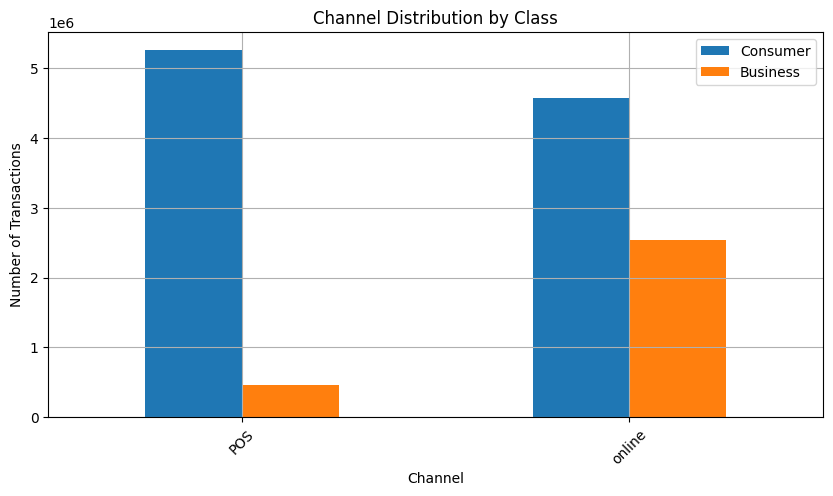

In [72]:
channel_dist = (
    data.groupby(["target", "channel"])
    .size()
    .reset_index(name="count")
)

channel_pivot = channel_dist.pivot(
    index="channel",
    columns="target",
    values="count"
).fillna(0)

channel_pivot.columns = ["Consumer", "Business"]

channel_pivot.plot(kind="bar", figsize=(10, 5))

plt.title("Channel Distribution by Class")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

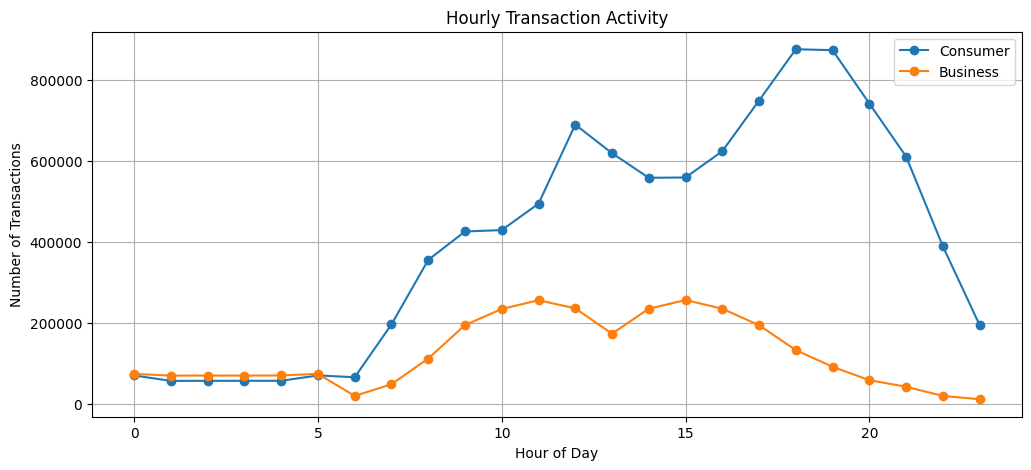

In [ ]:
# analyzing hourly activity
data["transaction_timestamp"] = pd.to_datetime(data["transaction_timestamp"])
data["hour"] = data["transaction_timestamp"].dt.hour

hourly_activity = data.groupby(["target", "hour"]).size().reset_index(name="count")

plt.figure(figsize=(12, 5))

for target, label in [(0, "Consumer"), (1, "Business")]:
    temp = hourly_activity[hourly_activity["target"] == target]
    plt.plot(temp["hour"], temp["count"], marker="o", label=label)

plt.title("Hourly Transaction Activity")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

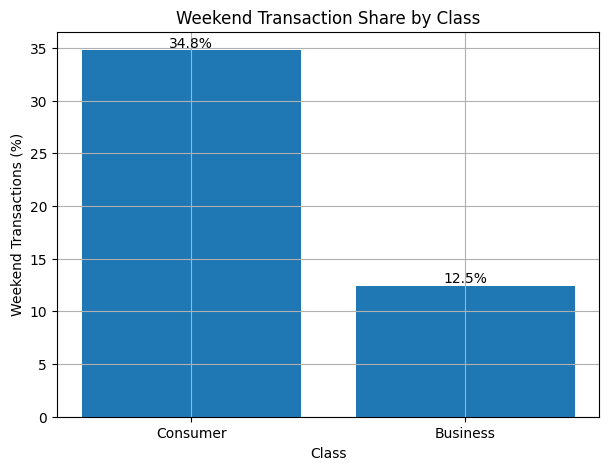

In [ ]:
# analyzing weekday vs weekend activity
data["weekday"] = data["transaction_timestamp"].dt.weekday
data["is_weekend"] = data["weekday"].isin([5, 6])

weekend_share = data.groupby("target")["is_weekend"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], weekend_share.values)

plt.title("Weekend Transaction Share by Class")
plt.xlabel("Class")
plt.ylabel("Weekend Transactions (%)")

for i, value in enumerate(weekend_share.values):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.show()

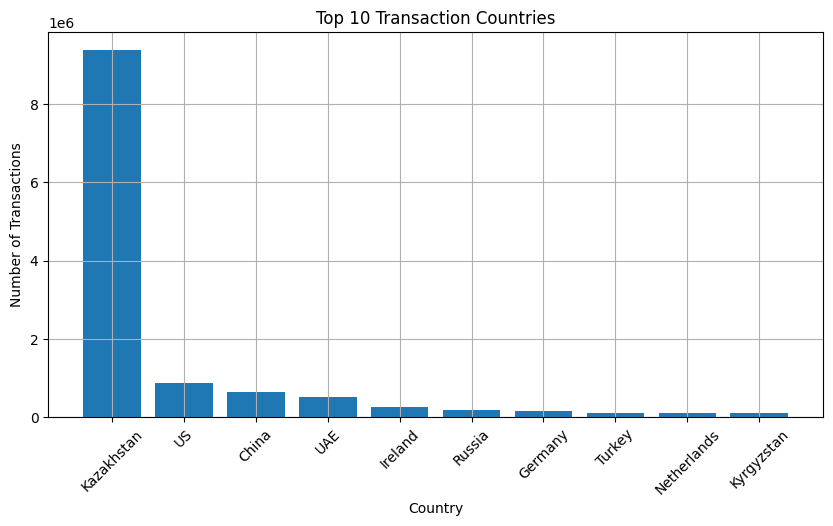

In [76]:
# analyzing top countries
top_countries = data["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_countries.index.astype(str), top_countries.values)

plt.title("Top 10 Transaction Countries")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

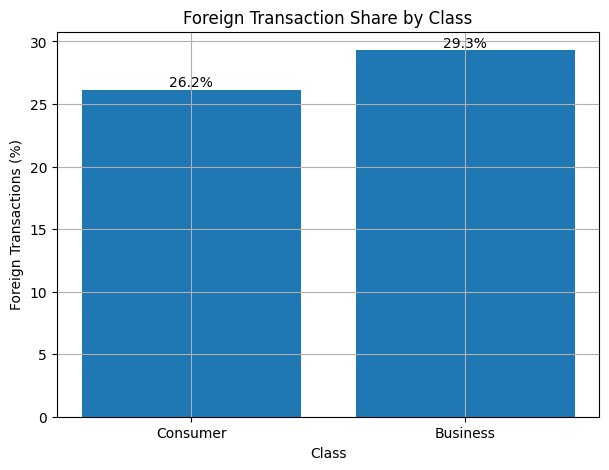

In [77]:
# foreign transactions share

data["is_foreign"] = data["country"] != "Kazakhstan"

foreign_share = data.groupby("target")["is_foreign"].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(["Consumer", "Business"], foreign_share.values)

plt.title("Foreign Transaction Share by Class")
plt.xlabel("Class")
plt.ylabel("Foreign Transactions (%)")

for i, value in enumerate(foreign_share.values):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.show()

In [81]:
# сохраняем промежуточные результаты для дальнейшего анализа
data.to_parquet("combined_data.parquet", index=False)